<a href="https://colab.research.google.com/github/Eno-stack/MLU/blob/main/math_lecture02_lab02_pcr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: right; font-family: Arial;"><hr width="15%" align="right" style="margin-bottom: -0.8em;"><h4>City Colleges of Chicago <h4></div>

<p style="padding: 10px; border: 1px solid black;">
<div style="background-image: linear-gradient(145deg, rgba(35, 47, 62, 1) 0%, rgba(51, 0, 102, 1) 40%, rgba(223, 42, 93, 1) 60%, rgba(124, 90, 237, 1) 85%, rgba(124, 232, 244, 1) 100%); padding: 20px; border-radius: 10px; text-align: center; margin-bottom: 30px;">
    <h1 style="color: white; margin: 0;">MLU: Mathematical Fundamentals for Machine Learning</h1>
    <h2 style="color: white; margin-top: 15px;">Dimensionality reduction and Principal Component Regression</h2>
</div>

<!-- Compact Lab Introduction with Activity/Challenge Explanation -->
<div style="background-color: #F8F9F9; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <h4 style="color: #2E4053; margin-top: 0;">About This Lab</h4>
    <p>Throughout this lab, you will encounter two types of interactive elements:</p>
    <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
        <tr>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="images/mlu-activity.png" alt="Activity" width="125"/>
            </td>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="images/mlu-challenge.png" alt="Challenge" width="125"/>
            </td>
        </tr>
        <tr>
            <td style="text-align: center; padding: 10px; background-color: #EBF5FB;">
                <p>No coding is needed for an activity. You try to understand a concept, <br/>answer questions, or run a code cell.</p>
            </td>
            <td style="text-align: center; padding: 10px; background-color: #FEF9E7;">
                <p>Challenges are where you test your understanding by implementing something new or taking a short quiz.</p>
            </td>
        </tr>
    </table>
    <p>Please work through this notebook from top to bottom to avoid errors due to missing code or context.</p>
</div>

<!-- Table of Contents with All Section Levels -->
<div style="background-color: #f2f0fc; padding: 15px; border-radius: 5px; margin-bottom: 30px;">
    <h2 style="color: #2f1381; border-bottom: 1px solid #2f1381; padding-bottom: 5px;">Table of Contents</h2>
    <p><a href="#section1" style="color: #2f1381; font-weight: bold; text-decoration: none;">1. Principal Component Analysis</a></p>
    <p><a href="#section2" style="color: #2f1381; font-weight: bold; text-decoration: none;">2. Visualization of the Fashion MNIST dataset</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section2-1" style="color: #2f1381; text-decoration: none;">2.1 Dimensionality reduction for data visualization with PCA</a></li>
    </ul>
    <p><a href="#section3" style="color: #2f1381; font-weight: bold; text-decoration: none;">3. Principal Component Regression</a></p>
</div>

**Principal Component Analysis (PCA)** is a popular technique for dimensionality reduction. In many datasets, there can be a lot of features (or variables), and some of them may be redundant or only add noise. PCA helps simplify these datasets by transforming them into a smaller set of new features, called principal components, which capture the most important information (variance) from the original data.

In this lab you will explore how PCA can be leveraged to visualize high-dimensional datasets and how to combine principal components with linear regression to build models with less features in what's called Principal Component Regression.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from IPython.display import Markdown, display

%matplotlib inline

<!-- Section Header -->
<div id="section1" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">1. Principal Component Analysis</h2>
</div>

Principal component analysis (PCA) is a statistical procedure that uses an orthogonal transformation to convert a set of observations of possibly correlated variables into a set of values of linearly uncorrelated variables called principal components. To do that, it leverages the eigendecomposition of symmetric matrices that you've seen in the Lecture 2 slides.

The transformation into principal components is defined in such a way that the first principal component has the largest possible variance. This means that it accounts for as much of the variability in the data as possible, and each succeeding component in turn has the highest variance possible under the constraint that it is orthogonal the preceding components. The resulting vectors are an uncorrelated orthogonal basis set.

PCA is sensitive to the relative scaling of the original variables.

#### Steps to compute the PCA

For a dataset represented by a matrix $X$, where each row is an observation and each column is a feature:

 - Center the Data: Subtract the mean of each feature so that the dataset has a mean of zero.
 - Compute Covariance Matrix: Calculate the covariance matrix of the data.
 - Calculate Eigenvalues and Eigenvectors: Compute the eigenvalues and eigenvectors of the covariance matrix. The eigenvectors represent the directions of the principal components, and the eigenvalues show the amount of variance captured by each component.
 - Sort and Select: Sort the eigenvectors by their eigenvalues in descending order and select the top $k$ eigenvectors. These are the directions of the $k$ principal components.

This transformation gives us a low-dimensional representation of the data that retains as much information (variance) as possible.

#### Scikit-learn implementation

In practice, PCA is implemented in `sklearn` as `sklearn.decomposition.PCA` as an object that learns the principal components in its `fit` method and can be used on new data to project it on these components. PCA centers but does not scale the input data for each feature before applying the decomposition. Thus, it is necessary to perform the scaling before sending the data to the PCA algorithm.

<!-- Section Header -->
<div id="section2" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">2. Visualization of the Fashion MNIST dataset</h2>
</div>

Fashion-MNIST is a dataset of Zalando's article images, consisting of a data set of 70,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes corresponding to fashion items. Each example is assigned to one of the following labels:

| Label | Description   |
|-------|---------------|
| 0     | T-shirt/top   |
| 1     | Trouser       |
| 2     | Pullover      |
| 3     | Dress         |
| 4     | Coat          |
| 5     | Sandal        |
| 6     | Shirt         |
| 7     | Sneaker       |
| 8     | Bag           |
| 9     | Ankle boot    |

Let's load the dataset and visualize some of its elements.

In [6]:
data = fetch_openml(name="Fashion-MNIST")
data.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [7]:
# Assemble features and target in same DataFrame for easy data handling
df = data["data"]
# Store target as integer
df["target"] = data["target"].astype(int)
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
1,0,0,0,0,0,1,0,0,0,0,...,114,130,76,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,22,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,33,96,...,0,0,0,0,0,0,0,0,0,3
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Each element in the dataset is an array of 28x28 pixels that can be seen as a vector of 784 features in total, corresponding to the gray scale of the pixel at each location on the 28x28 grid. The class label is an integer ranging from 0 to 9 according to the type of fashion item.

Let's visualize some of the images from this dataset, separated by classes. You can run the next cell several times, as it picks different random samples from the dataset each time.

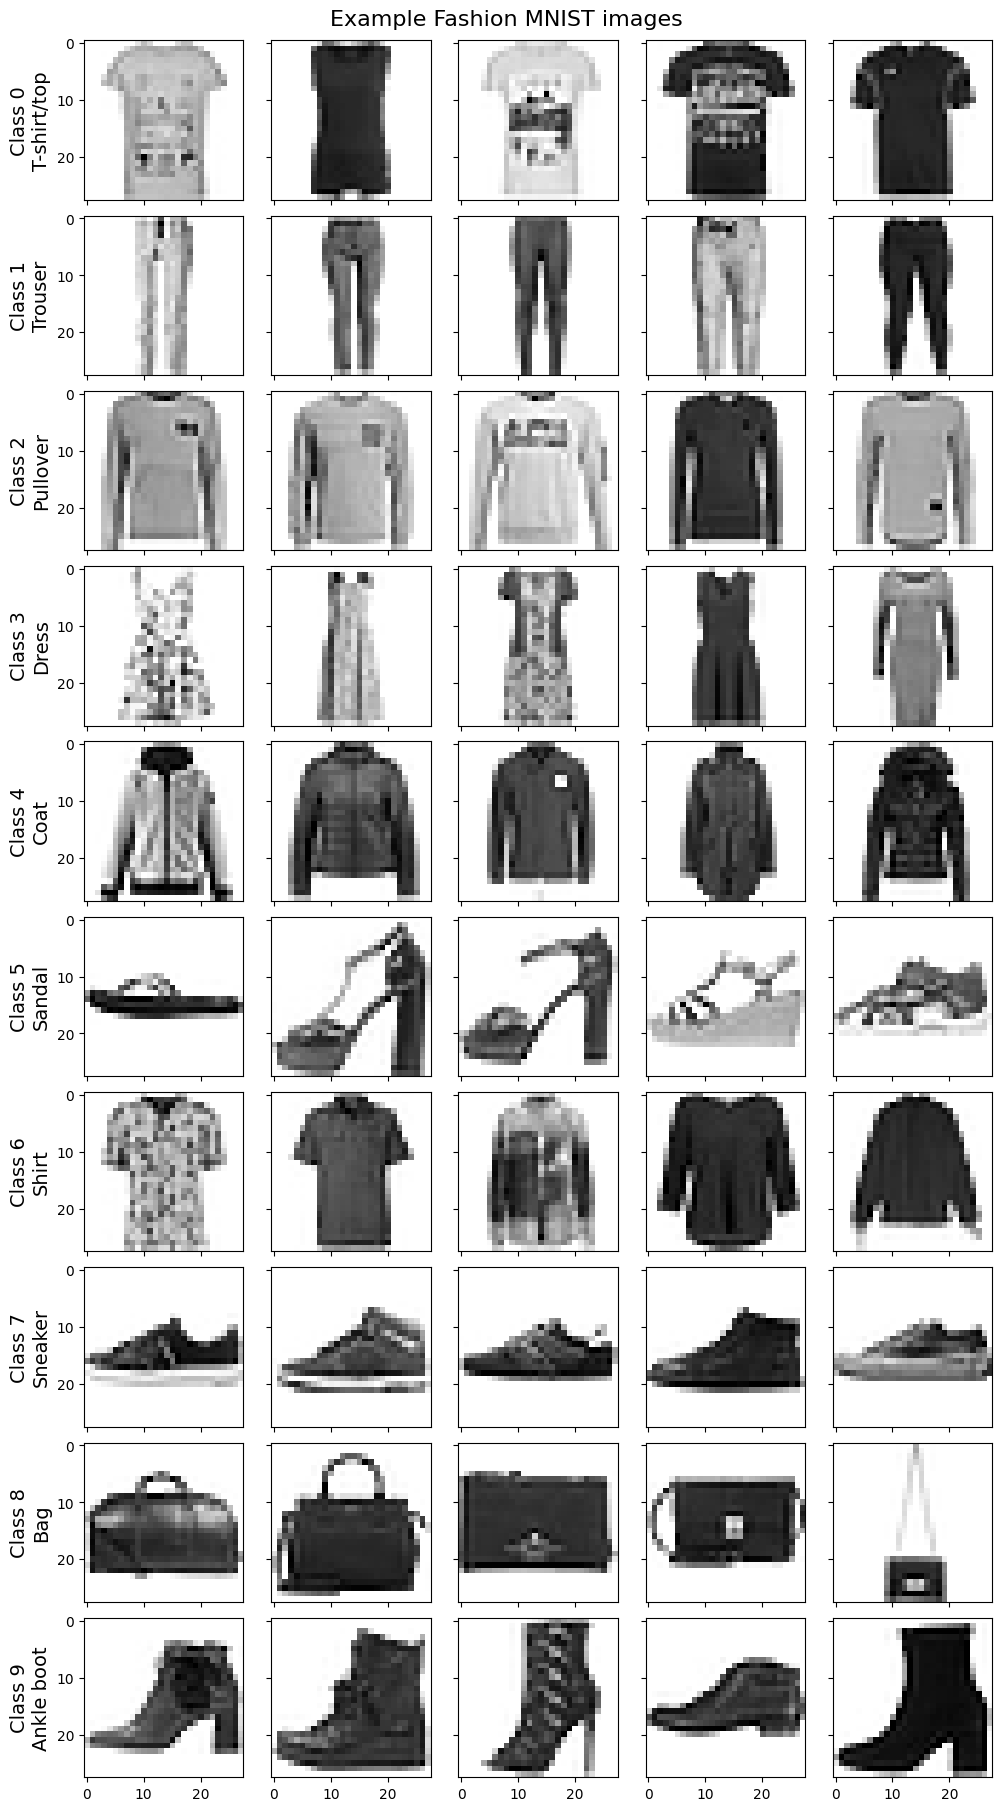

In [8]:
# The 10 classes are 0 to 9 and represent the types of items on the table above
label_description = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

# Convert class labels to integers for faster lookup
classes = sorted(label_description.keys())

# Group by target and take 5 samples from each class in advance
class_samples = {fashion_class: df[df.target == fashion_class].sample(n=5) for fashion_class in classes}

# Create the figure and axes once
fig, axes = plt.subplots(len(classes), 5, figsize=(10, 18), sharex=True, sharey=True, constrained_layout=True)
fig.suptitle("Example Fashion MNIST images", fontsize=16)

# Plotting the images
for i, fashion_class in enumerate(classes):
    # Set the y-axis label once per row
    axes[i, 0].set_ylabel(f"Class {fashion_class}\n{label_description[fashion_class]}", fontsize=14)

    # Access precomputed samples for the class and plot
    df_class = class_samples[fashion_class]
    for j in range(5):
        image = df_class.iloc[j, :784].astype(float).values.reshape(28, 28)  # Convert and reshape image once
        axes[i, j].imshow(image, cmap="gray_r")

plt.show()

<!-- Sub-subsection Header -->
<div id="section2-1" style="border-left: 2px solid #7b61ff; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h4 style="color: #7b61ff;">2.1 Dimensionality reduction for data visualization with PCA</h4>
</div>

The key idea of PCA for dimensionality reduction in data visualization is to transform high-dimensional data into a lower-dimensional space (typically 2D or 3D) while preserving as much of the data's variance (informative content) as possible. This helps us visualize complex datasets by capturing the most important patterns and structures in the data with just a few dimensions.

Let's apply PCA to the Fashion MNIST dataset to represent the images as 2D vectors that can be visualized on the plane.

We first need to scale the data before applying PCA. We'll apply `numpy`'s `StandardScaler` to standardize the features (pixels in the image) by removing the mean and scaling to unit variance.

In [9]:
# Scaler to normalize features
scaler = StandardScaler()

# Make a copy of the data so that pop doesn't overwrite df
# This allows this cell to be run multiple times without errors
df_ = df.copy()

# Remove the target as we'll only scale the features
y = df_.pop("target").values
X = df_.values

# Scaled features with zero mean and unit variance
X_sc = scaler.fit_transform(X)

# Shape of the input data
print(f"Shape of features matrix: {X_sc.shape}")

Shape of features matrix: (70000, 784)


Finally, let's perform PCA on the normalized data. Notice how PCA is an unsupervised ML algorithm that finds patterns on the standardized input features `X_sc` without looking at the labeled classes `y`.

The number of principal components to retain, given by `n_components`, is a hyperparameter of the algorithm. In this case we reduce the dimensions of the initial images to 2.

In [10]:
# Initialize PCA object
pca = PCA(n_components=2)

# Fit PCA to normalized data
X_2D = pca.fit_transform(X_sc)

# Shape of the data after PCA
print(f"Shape of the features matrix after PCA: {X_2D.shape}")

# Print one element of class 0 after the PCA
print(f"\nPCA representation of one element of class 0 (T-shirt/top): {X_2D[y==0][0]}")

Shape of the features matrix after PCA: (70000, 2)

PCA representation of one element of class 0 (T-shirt/top): [17.07338982 -4.96621704]


As seen above, each of the 70,000 elements of the dataset, originally a matrix of 28x28 = 764 elements, has now been reduced to a 2-dimensional vector, given in the basis of the 2 largest principal components from the PCA. Those 2 directions account for the maximum variance of the original dataset. It is to be expected that some patterns originally present in the high-dimensional data can be observed also in the two-dimensional representation.

Let's plot one of the Fashion MNIST classes, for instance class `0 = Tshirt/top`, and see how the projections on the 2 first principal components look like:

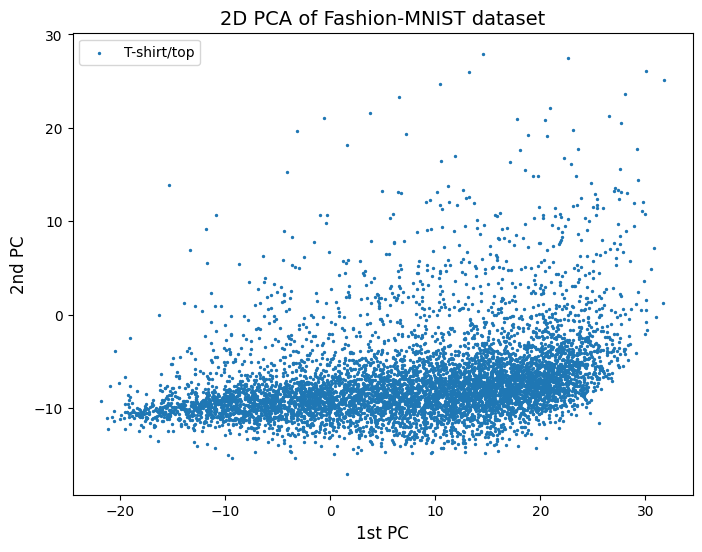

In [11]:
# Plot the class 0 = T-shirt/top
plt.figure(figsize=(8,6))

# Scatter plot of the fist component [:, 0] against the second [:, 1]
plt.scatter(X_2D[y==0][:, 0], X_2D[y==0][:, 1], s=2, label=label_description[0])
plt.title("2D PCA of Fashion-MNIST dataset", fontsize=14)
plt.xlabel("1st PC", fontsize=12)
plt.ylabel("2nd PC", fontsize=12)
plt.legend()

plt.show()

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="images/mlu-challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Visualize class separation of the Fashion MNIST dataset</h4>
        <p>Modify the plot above to show more than one class. You can plot all 10 classes, or choose groups of 2, 3 classes to better observe the structure.</p>
        <p><strong>Your task:</strong> Which classes do you think that will show a clearer separation in the space of the 2 first Principal Components? And which classes do you think that will overlap the most? Check your hypotheses.</p>
    </div>
</div>

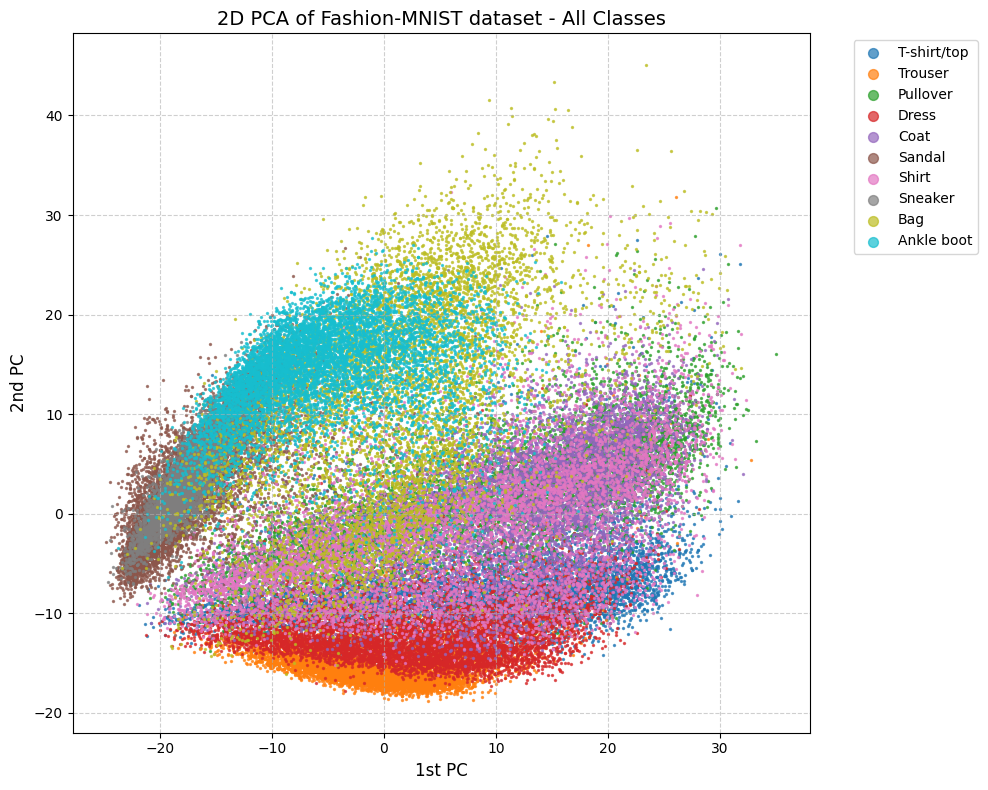

In [12]:
plt.figure(figsize=(10, 8))

for i, fashion_class in enumerate(classes):
    plt.scatter(X_2D[y == fashion_class][:, 0], X_2D[y == fashion_class][:, 1], s=2, label=label_description[fashion_class], alpha=0.7)

plt.title("2D PCA of Fashion-MNIST dataset - All Classes", fontsize=14)
plt.xlabel("1st PC", fontsize=12)
plt.ylabel("2nd PC", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> You can generalize the plotting code above by adding several scatter plots one after the other, or using a for loop. If you're stuck, remove the <code>#</code> before the <code>load</code> instruction in the next code cell to display a sample solution.</p>
</div>

In [ ]:
# %load solutions/lab22_ex1_solutions.txt



#### Learnings from visualization of high-dimensional data with PCA

The 2-dimensional plots obtained with PCA give an intuitive visual explanation of the structure of the high-dimensional data. Additionally, more dimensions in the construction of the PCA can be considered. For instance one can choose `n_components = 3` and plot the data in a 3-dimensional space. This type of unsupervised techniques are very useful in feature engineering and model selection to decide on the type of ML algorithm to be implemented. For instance, if the PCA shows a clear separation of the classes after reducing the dimensionality, it is likely that a simple linear-based classifier will be able to perform well on a low-dimensional representation of the original data. This can significantly ease the model training process.

<!-- Section Header -->
<div id="section3" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">3. Principal Component Regression</h2>
</div>

Principal Component Regression (PCR) combines PCA with linear regression on datasets with labeled numerical targets, i.e. for regression problems rather than classification. It is a way to build a regression model in cases where there are many correlated predictor variables, which can cause issues in regular regression. If we have too many features in our dataset, or if some features are highly correlated, linear regression models can suffer from overfitting and instability. PCR solves this problem by:

 - Reducing the number of features: Using only the top principal components instead of the original features.
 - Improving stability: The principal components are uncorrelated, so they work well in regression models without multicollinearity issues.

#### How PCR Works
1. Apply PCA on the predictor variables: First, we apply PCA to the predictor variables (independent variables) to reduce their dimensionality.
2. Select top $k$ components: Choose the top $k$ principal components that capture most of the variance in the predictors.
3. Apply linear regression: Use these $k$ principal components as the new predictors in a linear regression model to predict the target variable.

#### Diabetes data

For this example you will use the `diabetes` dataset, available in `sklearn`. This dataset contains data from diabetic patients, in particular certain features such as their bmi, age, blood pressure, and glucose levels which are useful in predicting the diabetes disease progression in patients. This data can be modeled with a linear regression approach. There expects to be a certain degree of multicollinearity in this data, thus it is worthwhile to explore whether PCA can help reduce the dimensionality of the dataset. This approach is called Principal Component Regression.

Let's start by loading and inspecting the dataset.

In [13]:
# Load the dataset
diabetes = load_diabetes(as_frame=True)

diabetes["data"].head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Important:</strong> Notice that this data already has its mean removed. Each of the 10 feature variables have been mean centered and scaled by the standard deviation times the square root of the number of sample, i.e. the sum of squares of each column totals 1. There's no need to further subtract the mean before sending the data to the PCA for this particular dataset, as it's already centered.</p>
</div>

In [14]:
# Check that the mean of each column is zero
diabetes["data"].describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [15]:
# The correlation of each of the features is 1 -- check that values in the diagonal equal 1
(diabetes["data"].T).dot(diabetes["data"])

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


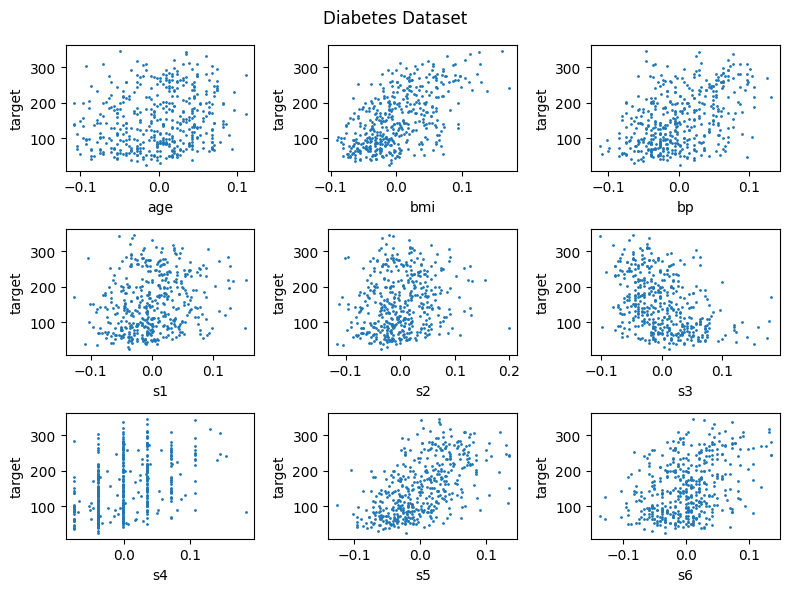

In [16]:
# Don't plot the sex data
features = diabetes["feature_names"]
features.remove("sex")

# Plot
fig, axs = plt.subplots(3, 3, figsize=(8, 6))
fig.suptitle("Diabetes Dataset")
for i in range(3):
    for j in range(3):
        n = j + i * 3
        feature = features[n]
        axs[i, j].scatter(diabetes["data"][feature], diabetes["target"], s=1)
        axs[i, j].set_xlabel(feature)
        axs[i, j].set_ylabel("target")
plt.tight_layout()
plt.show()

Let's fit a linear regression using `LinearRegression` as we did in Lab 1 - Ordinary Least Squares. We will compute MSE and $R^2$ for this multivariate regression problem using all 10 features from the dataset.

In [18]:
# Get features and target from dataframes
X = diabetes["data"].values
y = diabetes["target"].values

# Split data in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=47)

# Train model and print performance metrics
# Use sklearn implementation
lr = LinearRegression()
lr.fit(X_train, y_train)

print(f"sklearn LinearRegression model parameters: {lr.intercept_}, {lr.coef_}")
print(f"Number of sklearn LinearRegression model parameters: {1 + len(lr.coef_)}")
print()
print(f"sklearn LinearRegression training R2: {r2_score(y_train, lr.predict(X_train)):.4f}")
print(f"sklearn LinearRegression test R2: {r2_score(y_test, lr.predict(X_test)):.4f}")
print()
print(f"sklearn LinearRegression training MSE: {mean_squared_error(y_train, lr.predict(X_train)):.4f}")
print(f"sklearn LinearRegression test MSE: {mean_squared_error(y_test, lr.predict(X_test)):.4f}")
print()
print(f"sklearn LinearRegression training RMSE: {root_mean_squared_error(y_train, lr.predict(X_train)):.4f}")
print(f"sklearn LinearRegression test RMSE: {root_mean_squared_error(y_test, lr.predict(X_test)):.4f}")

# Store results for later plot
r2_score_train = r2_score(y_train, lr.predict(X_train))
r2_score_test = r2_score(y_test, lr.predict(X_test))

rmse_train = root_mean_squared_error(y_train, lr.predict(X_train))
rmse_test = root_mean_squared_error(y_test, lr.predict(X_test))

sklearn LinearRegression model parameters: 154.13394958869452, [  11.86872982 -225.53704115  517.77345246  283.79886893 -660.91557081
  411.17987198   13.37218494  110.67851834  735.40008921   79.51672165]
Number of sklearn LinearRegression model parameters: 11

sklearn LinearRegression training R2: 0.5376
sklearn LinearRegression test R2: 0.4309

sklearn LinearRegression training MSE: 2792.4074
sklearn LinearRegression test MSE: 3101.0484

sklearn LinearRegression training RMSE: 52.8432
sklearn LinearRegression test RMSE: 55.6871


<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="images/mlu-challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Implement Principal Component Regression on the diabetes dataset</h4>
        <p>Apply PCA to the data to obtain its principal components. Plot the percentange of the variance explained by each principal component.</p>
        <p><strong>Your task:</strong> Fit linear regression models to a subset of the transformed features, keeping those with the largest variance. What's an optimal dimensionality for the transformed dataset, that achieves good performance while keeping the dataset small?</p>
    </div>
</div>

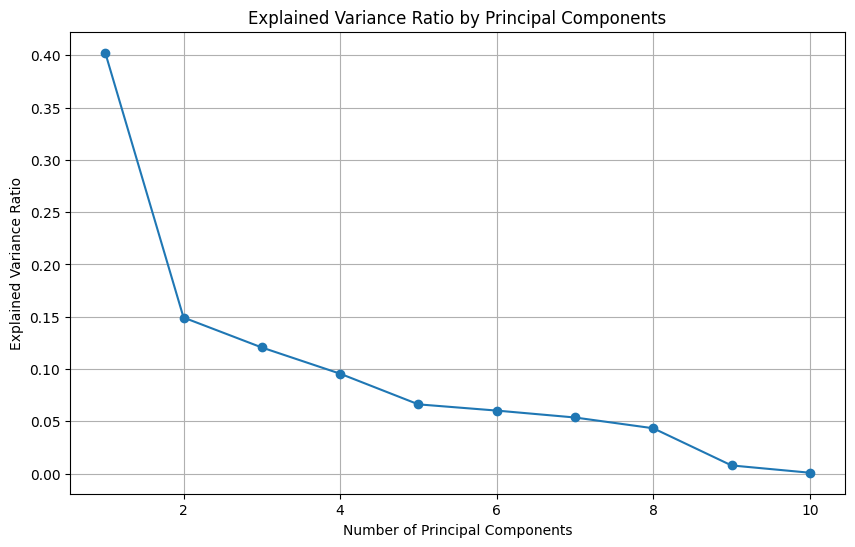

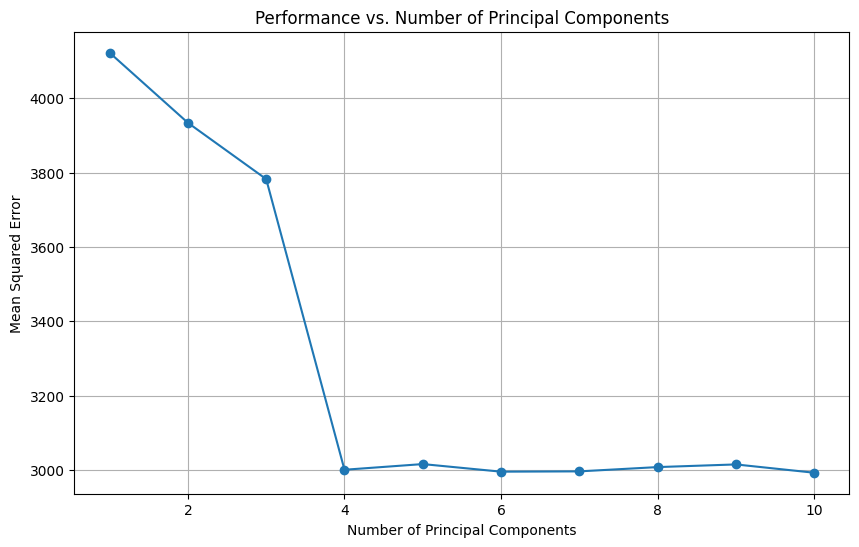

Best number of components: 1
Optimal number of components: 1


In [2]:
###### YOUR CODE HERE ######
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Load dataset
X, y =load_diabetes (return_X_y=True)

# Standardize features
scaler =StandardScaler ()
X_scaled = scaler.fit_transform(X)

# Apply PCA
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Components')
plt.grid(True)
plt.show()

#Test Regression performance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
results = []
for n in range(1, X_pca.shape[1] +1):
    X_subset = X_pca[:, :n]
    model = LinearRegression()
    model.fit(X_subset, y)

    scores = cross_val_score(model, X_subset, y, cv=5, scoring='neg_mean_squared_error')
    mse = -scores.mean()
    results.append(mse)


#Plot performance vs. dimensions
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(results) + 1), results, marker = 'o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Mean Squared Error')
plt.title('Performance vs. Number of Principal Components')
plt.grid(True)
plt.show()


#Find optimal number of components
best_n = np.argmax(results) + 1
best_score = max(results)
print(f"Best number of components: {best_n}")
print(f"Optimal number of components: {best_n}")



######## END OF CODE ########

<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> You can find the ratios of explained variance per number of chosen principal components in the attribute <code>.explained_variance_ratio</code> of a trained PCA. To estimate the optimal number of principal components for the PCR, we recommend fitting linear models to 1, 2, 3, ... principal components and compare standard performance metrics for linear regression, such as RMSE or R2, as a function of the number of chosen components. If you're stuck, remove the <code>#</code> before the <code>load</code> instruction in the next code cell to display a sample solution.</p>
</div>

In [3]:
# %load solutions/lab22_ex2_solutions.txt
I visualized Fashion MNIST data using PCA to observe class separation. For Principal Component Regression on the diabetes dataset, we found that using 1 principal component provided the optimal performance with the lowest Mean Squared Error.



<div style="background-color: #f2f0fc; padding: 15px; border-radius: 5px; margin: 30px 0;">
    <h3 style="color: #2f1381; border-bottom: 1px solid #2f1381; padding-bottom: 5px;">Conclusion</h3>
    <p style="color: #2f1381;">In this lab, you have:</p>
    <ul>
        <li style="color: #2f1381;">Learned about Principal Component Analysis (PCA) and how it can be used for dimensionality reduction</li>
        <li style="color: #2f1381;">Applied PCA to visualize the high-dimensional Fashion MNIST dataset in 2D</li>
        <li style="color: #2f1381;">Explored Principal Component Regression (PCR) on the diabetes dataset</li>
    </ul>
    <h4 style="color: #2f1381; margin-top: 15px;">Additional Resources</h4>
    <ul>
        <li><a href="https://scikit-learn.org/stable/modules/decomposition.html#pca">Scikit-learn PCA Documentation</a></li>
        <li><a href="https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_vs_lda.html">PCA vs LDA Example</a></li>
    </ul>
</div>

<p style="padding: 10px; border: 1px solid black;">
<div style="text-align: right; font-family: Arial;"><hr width="15%" align="right" style="margin-bottom: -0.8em;"><h4>City Colleges of Chicago <h4></div>

# Thank you!